## Project 3 - Value at Risk (VaR) & Expected Shortfall (ES)

### Imports and setup

In [39]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.6f}".format
np.set_printoptions(suppress=True, precision=6)


### Data download and sample definition

Two samples are created:

- a long baseline sample from `2015-02-20` to `2025-02-19`, used for the main VaR and ES calculations;
- a stressed sample from `2020-02-20` to `2021-02-19`, used only for the stressed-vs-baseline comparison.

The summary statistics printed here help check that the data was downloaded correctly and that both samples contain enough observations.


In [40]:
tickers = ["TSLA", "MSFT"]

baseline_start = "2015-02-20"
baseline_end = "2025-02-19"

stress_start = "2020-02-20"
stress_end = "2021-02-19"

data = yf.download(tickers, start=baseline_start, end=baseline_end, auto_adjust=False, progress=False)["Close"]
data = data.dropna()

stress_data = yf.download(tickers, start=stress_start, end=stress_end, auto_adjust=False, progress=False)["Close"]
stress_data = stress_data.dropna()

print("Baseline sample")
print(data.describe())
print()
print("Stressed sample")
print(stress_data.describe())


Baseline sample
Ticker         MSFT         TSLA
count  2,514.000000 2,514.000000
mean     192.476213   120.392377
std      124.504396   117.609931
min       40.290001     9.578000
25%       73.270002    17.504667
50%      162.729996    36.895332
75%      288.207489   223.654163
max      467.559998   479.859985

Stressed sample
Ticker       MSFT       TSLA
count  252.000000 252.000000
mean   200.644524 126.685280
std     24.342429  77.573684
min    135.419998  24.081333
25%    183.384995  54.618832
50%    208.144997 122.234665
75%    216.059998 159.315838
max    244.990005 294.363342


### Computing log and pct returns

This cell computes daily log returns for the baseline sample.

In [41]:
log_returns = np.log(data).diff().dropna()
pct_returns = data.pct_change().dropna()
stress_pct_returns = stress_data.pct_change().dropna()

print(pct_returns.describe())
print(log_returns.describe())


Ticker         MSFT         TSLA
count  2,513.000000 2,513.000000
mean       0.001034     0.001923
std        0.017030     0.036144
min       -0.147390    -0.210628
25%       -0.006793    -0.016348
50%        0.000912     0.001261
75%        0.009736     0.019256
max        0.142169     0.219190
Ticker         MSFT         TSLA
count  2,513.000000 2,513.000000
mean       0.000889     0.001272
std        0.017017     0.036042
min       -0.159453    -0.236518
25%       -0.006816    -0.016483
50%        0.000911     0.001260
75%        0.009689     0.019073
max        0.132929     0.198187


### Price history chart

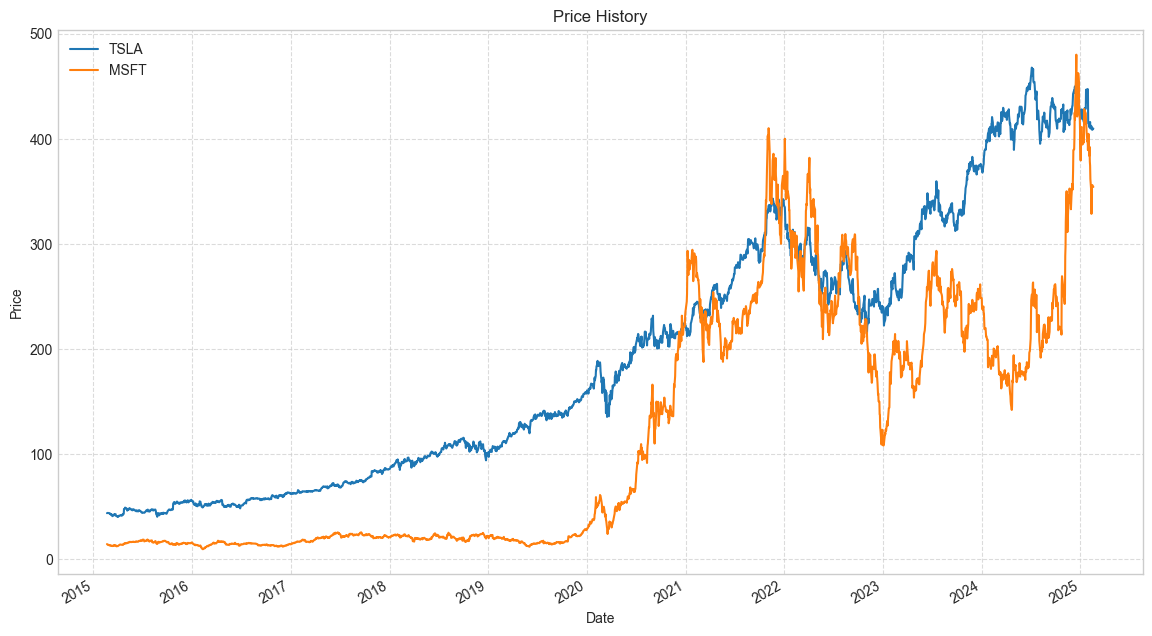

In [42]:
plt.figure(figsize=(14, 8))
data.plot(ax=plt.gca())
plt.title("Price History")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(tickers)
plt.grid(linestyle="--", alpha=0.7)
plt.show()


### Distribution diagnostics for the assets

These diagnostics help us judge whether the return distributions look close to normal or whether they display asymmetry and fat tails. That matters because the parametric VaR methods rely on stronger distributional assumptions than the non-parametric ones.


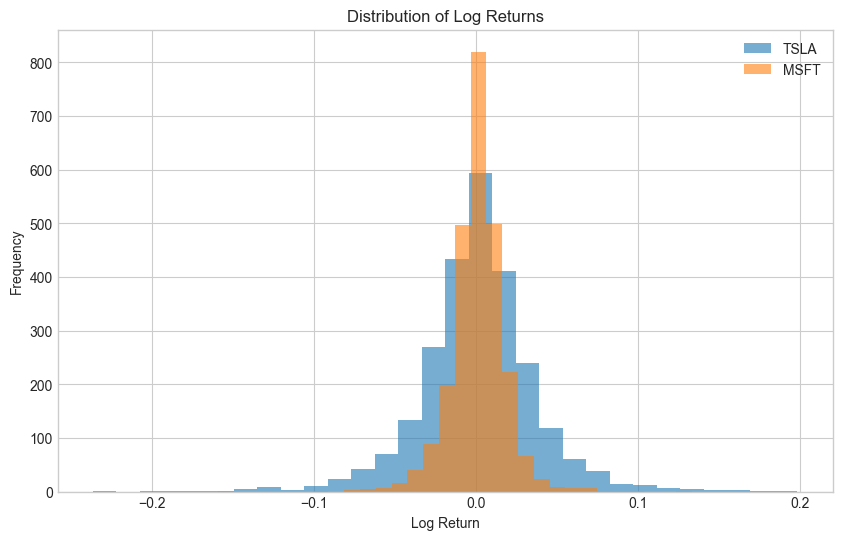

TSLA Skewness: -0.0575, Excess Kurtosis: 4.3314
MSFT Skewness: -0.1150, Excess Kurtosis: 7.9319


In [57]:
def sample_skew(x):
    x = np.asarray(x, dtype=float)
    n = len(x)
    m = x.mean()
    s = x.std(ddof=1)
    if s == 0 or n < 3:
        return np.nan
    return (n / ((n - 1) * (n - 2))) * np.sum(((x - m) / s) ** 3)


def sample_excess_kurtosis(x):
    x = np.asarray(x, dtype=float)
    n = len(x)
    m = x.mean()
    s = x.std(ddof=1)
    if s == 0 or n < 4:
        return np.nan
    term1 = (n * (n + 1) / ((n - 1) * (n - 2) * (n - 3))) * np.sum(((x - m) / s) ** 4)
    term2 = (3 * (n - 1) ** 2) / ((n - 2) * (n - 3))
    return term1 - term2


plt.figure(figsize=(10, 6))
plt.hist(log_returns["TSLA"], bins=30, alpha=0.6, label="TSLA")
plt.hist(log_returns["MSFT"], bins=30, alpha=0.6, label="MSFT")
plt.title("Distribution of Log Returns")
plt.xlabel("Log Return")
plt.ylabel("Frequency")
plt.legend()
plt.show()

tsla_stats = sample_skew(log_returns["TSLA"]), sample_excess_kurtosis(log_returns["TSLA"])
msft_stats = sample_skew(log_returns["MSFT"]), sample_excess_kurtosis(log_returns["MSFT"])

print(f"TSLA Skewness: {tsla_stats[0]:.4f}, Excess Kurtosis: {tsla_stats[1]:.4f}")
print(f"MSFT Skewness: {msft_stats[0]:.4f}, Excess Kurtosis: {msft_stats[1]:.4f}")


### Portfolio construction

This cell builds the two-asset portfolio using the current weights:

- `60%` in `TSLA`,
- `40%` in `MSFT`.

The portfolio value is fixed at `EUR 15,000`.

From the asset returns, the portfolio daily return is computed as:

$$
R_{p,t} = w_{TSLA}R_{TSLA,t} + w_{MSFT}R_{MSFT,t}
$$

The cell also constructs the equity curve of the portfolio, which gives a useful visual summary of how the investment would have evolved through time.


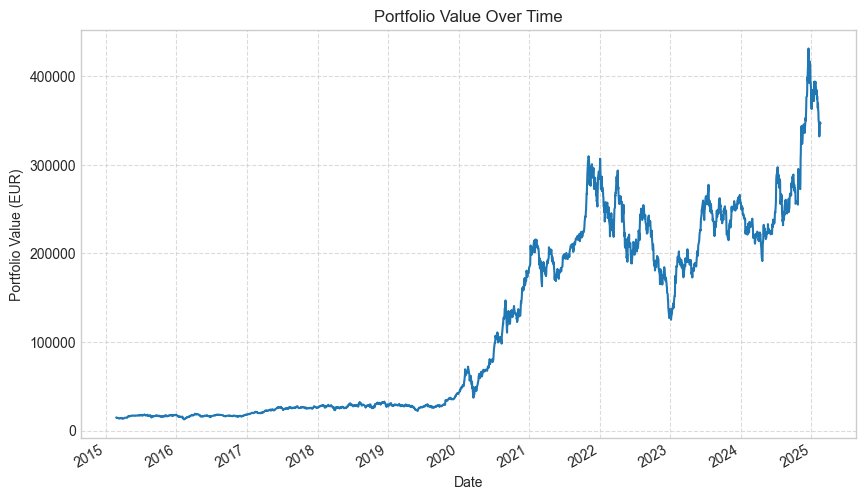

In [44]:
w_tsla = 0.6
w_msft = 0.4

portfolio_value = 15_000

port_ret = w_tsla * pct_returns["TSLA"] + w_msft * pct_returns["MSFT"]
stress_port_ret = w_tsla * stress_pct_returns["TSLA"] + w_msft * stress_pct_returns["MSFT"]

equity_curve = portfolio_value * (1 + port_ret).cumprod()

plt.figure(figsize=(10, 6))
equity_curve.plot(ax=plt.gca())
plt.title("Portfolio Value Over Time")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (EUR)")
plt.grid(linestyle="--", alpha=0.7)
plt.show()


### Portfolio return distribution

This cell summarizes the portfolio return series.

It computes:

- the 1% and 5% empirical quantiles,
- portfolio skewness,
- portfolio excess kurtosis,
- and a histogram of daily returns.

This is a natural bridge into the VaR section, because VaR is ultimately derived from the left tail of this return distribution.


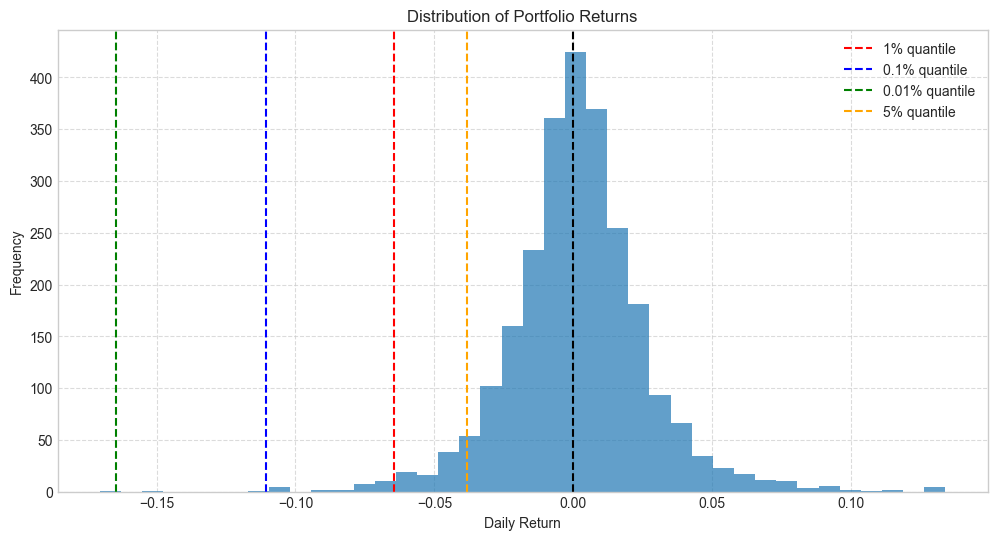

Portfolio Skewness: 0.0451
Portfolio Excess Kurtosis: 4.1626
5% portfolio return quantile: -0.0382
1% portfolio return quantile: -0.0647
0.1% portfolio return quantile: -0.1107
0.01% portfolio return quantile: -0.1648


In [ ]:
q001 = port_ret.quantile(0.0001)
q01 = port_ret.quantile(0.001)
q1 = port_ret.quantile(0.01)
q5 = port_ret.quantile(0.05)


plt.figure(figsize=(12, 6))
port_ret.hist(bins=40, alpha=0.7)
plt.title("Distribution of Portfolio Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.axvline(q1, color="red", linestyle="--", label="1% quantile")
plt.axvline(q01, color="blue", linestyle="--", label="0.1% quantile")
plt.axvline(q001, color="green", linestyle="--", label="0.01% quantile")
plt.axvline(q5, color="orange", linestyle="--", label="5% quantile")
plt.legend()
plt.grid(linestyle="--", alpha=0.7)
plt.show()

port_ret_skew = sample_skew(port_ret)
port_ret_kurt = sample_excess_kurtosis(port_ret)

print(f"Portfolio Skewness: {port_ret_skew:.4f}")
print(f"Portfolio Excess Kurtosis: {port_ret_kurt:.4f}")
print(f"5% portfolio return quantile: {q5:.4f}")
print(f"1% portfolio return quantile: {q1:.4f}")
print(f"0.1% portfolio return quantile: {q01:.4f}")
print(f"0.01% portfolio return quantile: {q001:.4f}")

### SMA parametric VaR implementation

This cell implements the simple moving average parametric VaR.

The parametric VaR return is computed as:

$$
VaR_{1\%} = -\left(\mu_t + z_{1\%}\sigma_t\right)
$$

and then converted into euros by multiplying by the portfolio value.

In [46]:
window = 252
z_1pct = -2.3263478740408408
z_5pct = -1.6448536269514729
z_10pct = -1.2815515655446004


def normal_pdf(x):
    return math.exp(-0.5 * x * x) / math.sqrt(2 * math.pi)


rolling_mu_sma = port_ret.rolling(window=window).mean()
rolling_std_sma = port_ret.rolling(window=window).std(ddof=1)

sma_var_return = -(rolling_mu_sma + z_1pct * rolling_std_sma)
sma_var_eur = portfolio_value * sma_var_return

print("Latest Value")
print(f"SMA VaR (1%, daily): {sma_var_return.iloc[-1]:.4f} ({sma_var_eur.iloc[-1]:.2f} EUR)")
print()
print("Worst Rolling Value")
print(f"SMA VaR (1%, daily): {sma_var_return.max():.4f} ({sma_var_eur.max():.2f} EUR)")
print()
print("Lowest Rolling Value")
print(f"SMA VaR (1%, daily): {sma_var_return.min():.4f} ({sma_var_eur.min():.2f} EUR)")


Latest Value
SMA VaR (1%, daily): 0.0593 (889.83 EUR)

Worst Rolling Value
SMA VaR (1%, daily): 0.0884 (1326.61 EUR)

Lowest Rolling Value
SMA VaR (1%, daily): 0.0293 (438.83 EUR)


### EWMA VaR implementation

This cell implements the exponentially weighted moving average approach with a fixed daily lambda:

$$
\lambda = 0.94
$$

The EWMA variance recursion is:

$$
\sigma_t^2 = \lambda \sigma_{t-1}^2 + (1-\lambda)r_{t-1}^2
$$

Compared with SMA, this approach reacts more quickly to recent shocks because newer observations receive more weight.
The VaR formula is then applied in the same way as in the parametric SMA case.


In [47]:
ewma_lambda = 0.94
print(f"EWMA lambda: {ewma_lambda:.2f}")


def ewma_volatility(returns, lam):
    returns = np.asarray(returns, dtype=float)
    var = np.zeros_like(returns)
    var[0] = np.var(returns, ddof=1)
    for i in range(1, len(returns)):
        var[i] = lam * var[i - 1] + (1 - lam) * returns[i - 1] ** 2
    return np.sqrt(var)


ewma_vol = pd.Series(ewma_volatility(port_ret.values, ewma_lambda), index=port_ret.index)
ewma_mu = port_ret.rolling(window=window).mean()
ewma_var_return = -(ewma_mu + z_1pct * ewma_vol)
ewma_var_eur = portfolio_value * ewma_var_return

ewma_var_return_valid = ewma_var_return.dropna()
ewma_var_eur_valid = ewma_var_eur.dropna()

print("Latest Value")
print(f"EWMA VaR (1%, daily): {ewma_var_return_valid.iloc[-1]:.4f} ({ewma_var_eur_valid.iloc[-1]:.2f} EUR)")
print()
print("Worst Rolling Value")
print(f"EWMA VaR (1%, daily): {ewma_var_return_valid.max():.4f} ({ewma_var_eur_valid.max():.2f} EUR)")
print()
print("Lowest Rolling Value")
print(f"EWMA VaR (1%, daily): {ewma_var_return_valid.min():.4f} ({ewma_var_eur_valid.min():.2f} EUR)")


EWMA lambda: 0.94
Latest Value
EWMA VaR (1%, daily): 0.0536 (804.51 EUR)

Worst Rolling Value
EWMA VaR (1%, daily): 0.1709 (2563.93 EUR)

Lowest Rolling Value
EWMA VaR (1%, daily): 0.0228 (341.33 EUR)


### Historical simulation VaR implementation

This cell implements the non-parametric historical VaR, so instead of assuming normality, it takes the rolling 1% empirical quantile of the portfolio returns and converts that tail loss into a positive VaR measure.

This method is interesting because it keeps the realized shape of the return distribution, including skewness and fat tails.


In [48]:
historical_var_return = (-port_ret.rolling(window=window).quantile(0.01)).dropna()
historical_var_eur = portfolio_value * historical_var_return

print("Latest Value")
print(f"Historical VaR (1%, daily): {historical_var_return.iloc[-1]:.4f} ({historical_var_eur.iloc[-1]:.2f} EUR)")
print()
print("Worst Rolling Value")
print(f"Historical VaR (1%, daily): {historical_var_return.max():.4f} ({historical_var_eur.max():.2f} EUR)")
print()
print("Lowest Rolling Value")
print(f"Historical VaR (1%, daily): {historical_var_return.min():.4f} ({historical_var_eur.min():.2f} EUR)")


Latest Value
Historical VaR (1%, daily): 0.0589 (883.01 EUR)

Worst Rolling Value
Historical VaR (1%, daily): 0.1107 (1661.24 EUR)

Lowest Rolling Value
Historical VaR (1%, daily): 0.0307 (460.95 EUR)


### Filtered historical simulation VaR implementation

The logic is:

1. estimate rolling volatility;
2. standardize past returns by that volatility;
3. rescale the standardized shocks with the current volatility level;
4. compute the 1% quantile of those filtered returns.

This method is often seen as a compromise between a pure historical method and a parametric volatility model, because it keeps empirical shocks while adjusting for changing volatility regimes.


In [49]:
rolling_vol = port_ret.rolling(window=window).std(ddof=1)

fhs_values = []
fhs_index = []

for i in range(window - 1, len(port_ret)):
    returns_window = port_ret.iloc[i - window + 1 : i + 1].values
    vol_window = rolling_vol.iloc[i - window + 1 : i + 1].values

    if np.any(np.isnan(vol_window)) or np.any(vol_window <= 0):
        continue

    standardized = returns_window / vol_window
    current_vol = vol_window[-1]
    filtered_returns = current_vol * standardized
    fhs_values.append(-np.quantile(filtered_returns, 0.01))
    fhs_index.append(port_ret.index[i])

hybrid_var_return = pd.Series(fhs_values, index=fhs_index)
hybrid_var_eur = portfolio_value * hybrid_var_return

print("Latest Value")
print(f"Filtered Historical VaR (1%, daily): {hybrid_var_return.iloc[-1]:.4f} ({hybrid_var_eur.iloc[-1]:.2f} EUR)")
print()
print("Worst Rolling Value")
print(f"Filtered Historical VaR (1%, daily): {hybrid_var_return.max():.4f} ({hybrid_var_eur.max():.2f} EUR)")
print()
print("Lowest Rolling Value")
print(f"Filtered Historical VaR (1%, daily): {hybrid_var_return.min():.4f} ({hybrid_var_eur.min():.2f} EUR)")


Latest Value
Filtered Historical VaR (1%, daily): 0.0665 (997.87 EUR)

Worst Rolling Value
Filtered Historical VaR (1%, daily): 0.1673 (2509.70 EUR)

Lowest Rolling Value
Filtered Historical VaR (1%, daily): 0.0236 (354.53 EUR)


### Monte Carlo VaR implementation

This cell implements a Monte Carlo VaR using simulated one-day joint returns for the two assets.

The simulation uses:

- the recent mean vector of asset returns,
- the recent covariance matrix,
- a Cholesky decomposition to preserve the dependence structure.

For robustness, the simulation is repeated multiple times and the median VaR across runs is reported as the main estimate.


In [50]:
np.random.seed(42)
n_simulations = 20_000
n_runs = 100

window_asset_returns = pct_returns.iloc[-window:]
mu_vec = window_asset_returns.mean().values
cov_mat = window_asset_returns.cov().values
chol = np.linalg.cholesky(cov_mat)

mc_var_estimates = []

for _ in range(n_runs):
    z = np.random.standard_normal((n_simulations, len(tickers)))
    simulated_asset_returns = mu_vec + z @ chol.T
    simulated_portfolio_returns = w_tsla * simulated_asset_returns[:, 0] + w_msft * simulated_asset_returns[:, 1]
    simulated_losses = -portfolio_value * simulated_portfolio_returns
    mc_var_estimates.append(np.quantile(simulated_losses, 0.99))

mc_var_daily = float(np.median(mc_var_estimates))
mc_var_worst = float(np.max(mc_var_estimates))
mc_var_lowest = float(np.min(mc_var_estimates))

print("Median Value")
print(f"Monte Carlo VaR (1%, daily): {mc_var_daily / portfolio_value:.4f} ({mc_var_daily:.2f} EUR)")
print()
print("Worst Simulation Run")
print(f"Monte Carlo VaR (1%, daily): {mc_var_worst / portfolio_value:.4f} ({mc_var_worst:.2f} EUR)")
print()
print("Lowest Simulation Run")
print(f"Monte Carlo VaR (1%, daily): {mc_var_lowest / portfolio_value:.4f} ({mc_var_lowest:.2f} EUR)")


Median Value
Monte Carlo VaR (1%, daily): 0.0452 (678.35 EUR)

Worst Simulation Run
Monte Carlo VaR (1%, daily): 0.0466 (698.36 EUR)

Lowest Simulation Run
Monte Carlo VaR (1%, daily): 0.0440 (659.83 EUR)


### VaR comparison and plots

This cell gathers the VaR estimates from all methods into one summary.

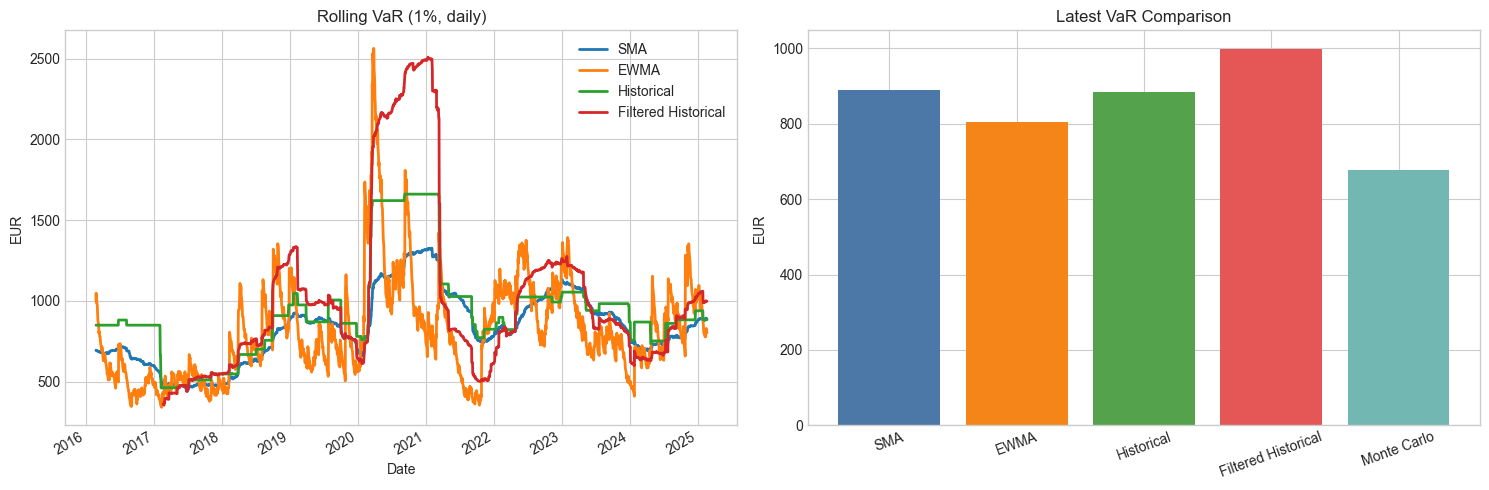

             Method  VaR (1%, daily, EUR)
Filtered Historical            997.867276
                SMA            889.830443
         Historical            883.011372
               EWMA            804.512897
        Monte Carlo            678.354197


In [51]:
var_methods = {
    "SMA": sma_var_eur.iloc[-1],
    "EWMA": ewma_var_eur_valid.iloc[-1],
    "Historical": historical_var_eur.iloc[-1],
    "Filtered Historical": hybrid_var_eur.iloc[-1],
    "Monte Carlo": mc_var_daily,
}

methods = list(var_methods.keys())
values = [var_methods[m] for m in methods]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

rolling_plot = pd.DataFrame(
    {
        "SMA": sma_var_eur,
        "EWMA": ewma_var_eur_valid.reindex(sma_var_eur.index),
        "Historical": historical_var_eur.reindex(sma_var_eur.index),
        "Filtered Historical": hybrid_var_eur.reindex(sma_var_eur.index),
    }
)
rolling_plot.plot(ax=axes[0], linewidth=2)
axes[0].set_title("Rolling VaR (1%, daily)")
axes[0].set_ylabel("EUR")

axes[1].bar(methods, values, color=["#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2"])
axes[1].set_title("Latest VaR Comparison")
axes[1].set_ylabel("EUR")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

summary_df = pd.DataFrame({"Method": methods, "VaR (1%, daily, EUR)": values}).sort_values("VaR (1%, daily, EUR)", ascending=False)
print(summary_df.to_string(index=False))


#### Comments and Interpretation

- SMA is the baseline parametric measure.
- EWMA reacts more quickly to volatility clustering.
- Historical VaR keeps the empirical tail behavior.
- Filtered Historical VaR adjusts old shocks to the current volatility regime.
- Monte Carlo VaR is smoother, but it still depends on the simulation assumptions.

The main comparison should be made with the latest values. The rolling worst and lowest values are only there to show how the estimate changes across regimes.


#### Parametric SMA: Weekly, Monthly, Annual VaR (1%) and Conversion to VaR (10%)
Methodology: start from the latest SMA mean and volatility, scale them by horizon, and change the z-score when moving from 1% to 10%.


It uses the standard square-root-of-time scaling for volatility:

$$
\sigma_h = \sigma_1 \sqrt{h}
$$

and then recomputes the VaR at 1% and 10% for each horizon.


In [52]:
mu_daily = rolling_mu_sma.iloc[-1]
sigma_daily_sma = rolling_std_sma.iloc[-1]

horizons = {
    "Weekly (5d)": 5,
    "Monthly (21d)": 21,
    "Annual (252d)": 252,
}

sma_horizon_rows = []

for horizon, h in horizons.items():
    mu_h = mu_daily * h
    sigma_h = sigma_daily_sma * np.sqrt(h)

    var_1pct_return = -(mu_h + z_1pct * sigma_h)
    var_10pct_return = -(mu_h + z_10pct * sigma_h)

    sma_horizon_rows.append(
        {
            "Horizon": horizon,
            "VaR 1% (return)": var_1pct_return,
            "VaR 1% (EUR)": var_1pct_return * portfolio_value,
            "VaR 10% (return)": var_10pct_return,
            "VaR 10% (EUR)": var_10pct_return * portfolio_value,
        }
    )

sma_horizon_var_df = pd.DataFrame(sma_horizon_rows)
print(sma_horizon_var_df.to_string(index=False))


      Horizon  VaR 1% (return)  VaR 1% (EUR)  VaR 10% (return)  VaR 10% (EUR)
  Weekly (5d)         0.127078  1,906.170755          0.065480     982.200884
Monthly (21d)         0.238762  3,581.434804          0.112524   1,687.860048
Annual (252d)         0.465854  6,987.808211          0.028552     428.272842


#### Non-Parametric Stressed VaR (1%) and Comparison to Baseline Historical VaR
Methodology: keep the same portfolio weights, compute the stressed return series over the crisis year, then compare the stressed 1% historical VaR to the baseline historical VaR.


Stressed historical VaR compares:

- the baseline historical VaR from the full sample,
- the stressed historical VaR from the crisis sample.

The goal is to show how much more severe the left tail becomes in a clearly stressed market regime.
The bar chart makes that comparison immediate and easy to comment on.


Stressed Historical VaR (1%)
Stress period: 2020-02-20 to 2021-02-19
Stressed VaR (1%, daily): 0.1108 (1661.92 EUR)

Comparison with baseline historical VaR
Baseline VaR (1%, daily): 0.0647 (970.14 EUR)
Difference: 691.78 EUR
Percentage change: 71.31%


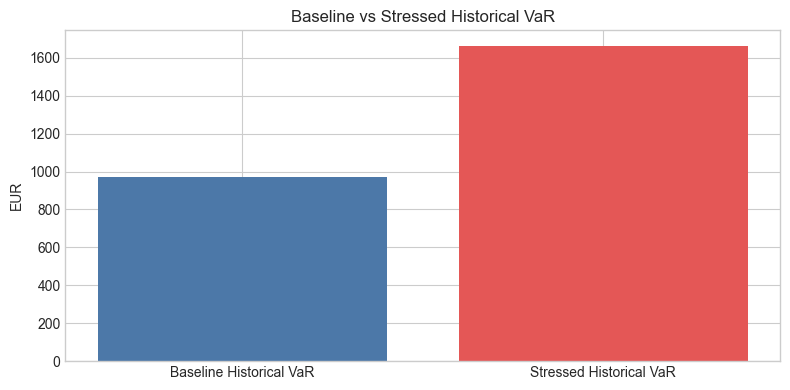

In [ ]:
baseline_nonparam_var_return = -port_ret.quantile(0.01)
baseline_nonparam_var_eur = baseline_nonparam_var_return * portfolio_value

stressed_var_return = -stress_port_ret.quantile(0.01)
stressed_var_eur = stressed_var_return * portfolio_value

delta_eur = stressed_var_eur - baseline_nonparam_var_eur
pct_change = (stressed_var_eur / baseline_nonparam_var_eur - 1) * 100

print("Stressed Historical VaR (1%)")
print(f"Stress period: {stress_start} to {stress_end}")
print(f"Stressed VaR (1%, daily): {stressed_var_return:.4f} ({stressed_var_eur:.2f} EUR)")
print()
print("Comparison with baseline historical VaR")
print(f"Baseline VaR (1%, daily): {baseline_nonparam_var_return:.4f} ({baseline_nonparam_var_eur:.2f} EUR)")
print(f"Difference: {delta_eur:.2f} EUR")
print(f"Percentage change: {pct_change:.2f}%")


#### 8. Option VaR using the Taylor Series Approximation
Methodology: reuse the call-option setup from the options project, simulate 20,000 GBM terminal prices, and approximate option PnL with a delta-gamma Taylor expansion.


Call price at t=0: 130.9263
Delta: 0.725391
Gamma: 0.00129334
Taylor VaR (1%): 170.2835


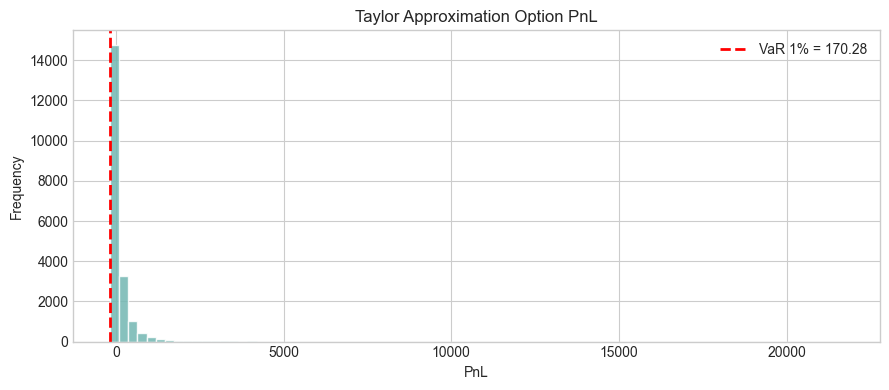

In [54]:
def normal_cdf(x):
    return 0.5 * (1 + math.erf(x / math.sqrt(2)))


def normal_pdf_scalar(x):
    return math.exp(-0.5 * x * x) / math.sqrt(2 * math.pi)


def bs_d1_d2(S, K, T, r, sigma):
    d1 = (math.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    return d1, d2


def bs_call_price(S, K, T, r, sigma):
    d1, d2 = bs_d1_d2(S, K, T, r, sigma)
    return S * normal_cdf(d1) - K * math.exp(-r * T) * normal_cdf(d2)


def bs_call_delta_gamma(S, K, T, r, sigma):
    d1, _ = bs_d1_d2(S, K, T, r, sigma)
    delta = normal_cdf(d1)
    gamma = normal_pdf_scalar(d1) / (S * sigma * math.sqrt(T))
    return delta, gamma


option_S0 = 417.44
option_K = 361.10
option_T = 1.0
option_r = 0.0342
option_sigma = 0.6176

option_delta, option_gamma = bs_call_delta_gamma(option_S0, option_K, option_T, option_r, option_sigma)
option_price_0 = bs_call_price(option_S0, option_K, option_T, option_r, option_sigma)

np.random.seed(42)
z = np.random.standard_normal(20_000)
option_ST = option_S0 * np.exp((option_r - 0.5 * option_sigma**2) * option_T + option_sigma * np.sqrt(option_T) * z)
delta_S = option_ST - option_S0

taylor_option_pnl = option_delta * delta_S + 0.5 * option_gamma * (delta_S ** 2)
taylor_option_losses = -taylor_option_pnl
taylor_var_1pct = np.quantile(taylor_option_losses, 0.99)

print(f"Call price at t=0: {option_price_0:.4f}")
print(f"Delta: {option_delta:.6f}")
print(f"Gamma: {option_gamma:.8f}")
print(f"Taylor VaR (1%): {taylor_var_1pct:.4f}")

plt.figure(figsize=(9, 4))
plt.hist(taylor_option_pnl, bins=80, color="#72B7B2", alpha=0.85, edgecolor="white")
plt.axvline(-taylor_var_1pct, color="red", linestyle="--", linewidth=2, label=f"VaR 1% = {taylor_var_1pct:.2f}")
plt.title("Taylor Approximation Option PnL")
plt.xlabel("PnL")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


#### Expected Shortfall for the Parametric and Non-Parametric Approaches
Methodology: compute ES at the 5% tail. For the parametric case use the Gaussian formula; for the non-parametric case average the empirical losses beyond the 95th percentile.


           Measure  Value (EUR)
Parametric ES (5%)   785.564049
Historical ES (5%)   840.778794


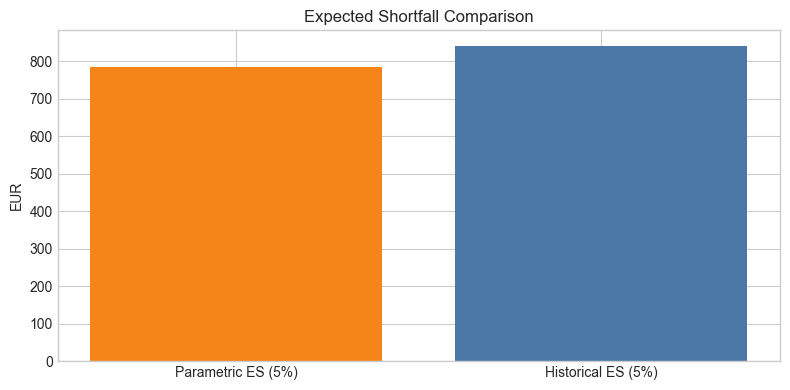

In [55]:
latest_mu = rolling_mu_sma.iloc[-1]
latest_sigma = rolling_std_sma.iloc[-1]

parametric_es_5pct_return = -(latest_mu - latest_sigma * normal_pdf(z_5pct) / 0.05)
parametric_es_5pct_eur = portfolio_value * parametric_es_5pct_return

historical_losses_full = -portfolio_value * port_ret.values
historical_var_5pct_eur = np.quantile(historical_losses_full, 0.95)
historical_es_5pct_eur = historical_losses_full[historical_losses_full >= historical_var_5pct_eur].mean()

es_df = pd.DataFrame(
    {
        "Measure": ["Parametric ES (5%)", "Historical ES (5%)"],
        "Value (EUR)": [parametric_es_5pct_eur, historical_es_5pct_eur],
    }
)

print(es_df.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.bar(es_df["Measure"], es_df["Value (EUR)"], color=["#F58518", "#4C78A8"])
plt.ylabel("EUR")
plt.title("Expected Shortfall Comparison")
plt.tight_layout()
plt.show()


#### VaR with Full Repricing
Methodology: use historical TSLA daily return factors, shock the current TSLA spot, fully reprice a one-month ATM call under each scenario, and take the 1% tail of the resulting loss distribution.


Current option value: 25.6243
Full Repricing VaR (1%): 14.0150

           Measure      Value
Full Repricing VaR  14.015047
        Taylor VaR 170.283469
 Portfolio SMA VaR 889.830443


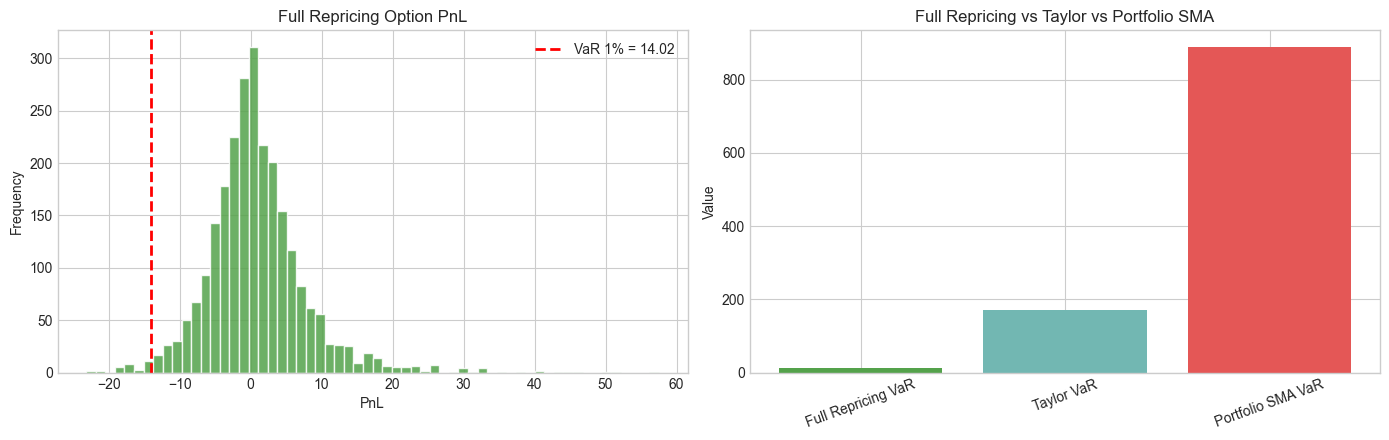

In [56]:
tsla_prices = data["TSLA"].dropna()
tsla_return_factors = (tsla_prices / tsla_prices.shift(1)).dropna()

fullrepr_S0 = float(tsla_prices.iloc[-1])
fullrepr_K = fullrepr_S0
fullrepr_T = 1 / 12
fullrepr_sigma = option_sigma
fullrepr_r = option_r

current_call_value = bs_call_price(fullrepr_S0, fullrepr_K, fullrepr_T, fullrepr_r, fullrepr_sigma)

shocked_prices = fullrepr_S0 * tsla_return_factors.values
repriced_calls = np.array([bs_call_price(s, fullrepr_K, fullrepr_T, fullrepr_r, fullrepr_sigma) for s in shocked_prices])

fullrepr_pnl = repriced_calls - current_call_value
fullrepr_losses = -fullrepr_pnl
fullrepr_var_1pct = np.quantile(fullrepr_losses, 0.99)

comparison_df = pd.DataFrame(
    {
        "Measure": [
            "Full Repricing VaR",
            "Taylor VaR",
            "Portfolio SMA VaR",
        ],
        "Value": [
            fullrepr_var_1pct,
            taylor_var_1pct,
            sma_var_eur.iloc[-1],
        ],
    }
)

print(f"Current option value: {current_call_value:.4f}")
print(f"Full Repricing VaR (1%): {fullrepr_var_1pct:.4f}")
print()
print(comparison_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(fullrepr_pnl, bins=60, color="#54A24B", alpha=0.85, edgecolor="white")
axes[0].axvline(-fullrepr_var_1pct, color="red", linestyle="--", linewidth=2, label=f"VaR 1% = {fullrepr_var_1pct:.2f}")
axes[0].set_title("Full Repricing Option PnL")
axes[0].set_xlabel("PnL")
axes[0].set_ylabel("Frequency")
axes[0].legend()

axes[1].bar(comparison_df["Measure"], comparison_df["Value"], color=["#54A24B", "#72B7B2", "#E45756"])
axes[1].set_title("Full Repricing vs Taylor vs Portfolio SMA")
axes[1].set_ylabel("Value")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()
